# Premier League match prediction — walkthrough

This notebook tells the whole story from raw data to final results, in the order you would present it. All the heavy lifting lives in `src/eplpred/` and `scripts/`, so every cell here is short.

**Question:** Before a Premier League match kicks off, can we predict the probability of a home win, a draw and an away win?

**Data:** every Premier League match from 2000-01 to 2025-26 (9,880 matches, 26 seasons) from Football-Data.co.uk. Full list of sources in `SOURCES.md`.

In [1]:
import pandas as pd
from IPython.display import Image, display

from eplpred import config, data, features

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)
FIG = config.FIGURES_DIR

## 1. The data
One row per match: teams, score, and match statistics (shots, shots on target, corners, fouls, cards).

In [2]:
matches = data.load_matches()
data.data_summary(matches).T

,0
matches,9880
seasons,26
teams,46
first_match,2000-08-19
last_match,2026-05-24
home_win_%,45.7
draw_%,24.8
away_win_%,29.5
with_odds_%,98.2


In [3]:
matches[['season_label', 'date', 'home_team', 'away_team', 'home_goals', 'away_goals', 'result',
         'home_shots', 'away_shots', 'home_shots_on_target', 'away_shots_on_target']].tail()

,season_label,date,home_team,away_team,home_goals,away_goals,result,home_shots,away_shots,home_shots_on_target,away_shots_on_target
9875,2025-26,2026-05-24,Manchester City,Aston Villa,1,2,A,16,12,3,5
9876,2025-26,2026-05-24,Nottingham Forest,Bournemouth,1,1,D,15,17,5,4
9877,2025-26,2026-05-24,Sunderland,Chelsea,2,1,H,20,10,2,1
9878,2025-26,2026-05-24,Tottenham Hotspur,Everton,1,0,H,21,8,6,3
9879,2025-26,2026-05-24,West Ham United,Leeds United,3,0,H,16,13,9,3


### How often does each result happen?
Home teams win about 46 % of matches, so a model that always says "home win" is already right 46 % of the time. That's the baseline we have to beat. In 2020-21, when matches were played without fans because of COVID-19, home advantage almost disappeared.

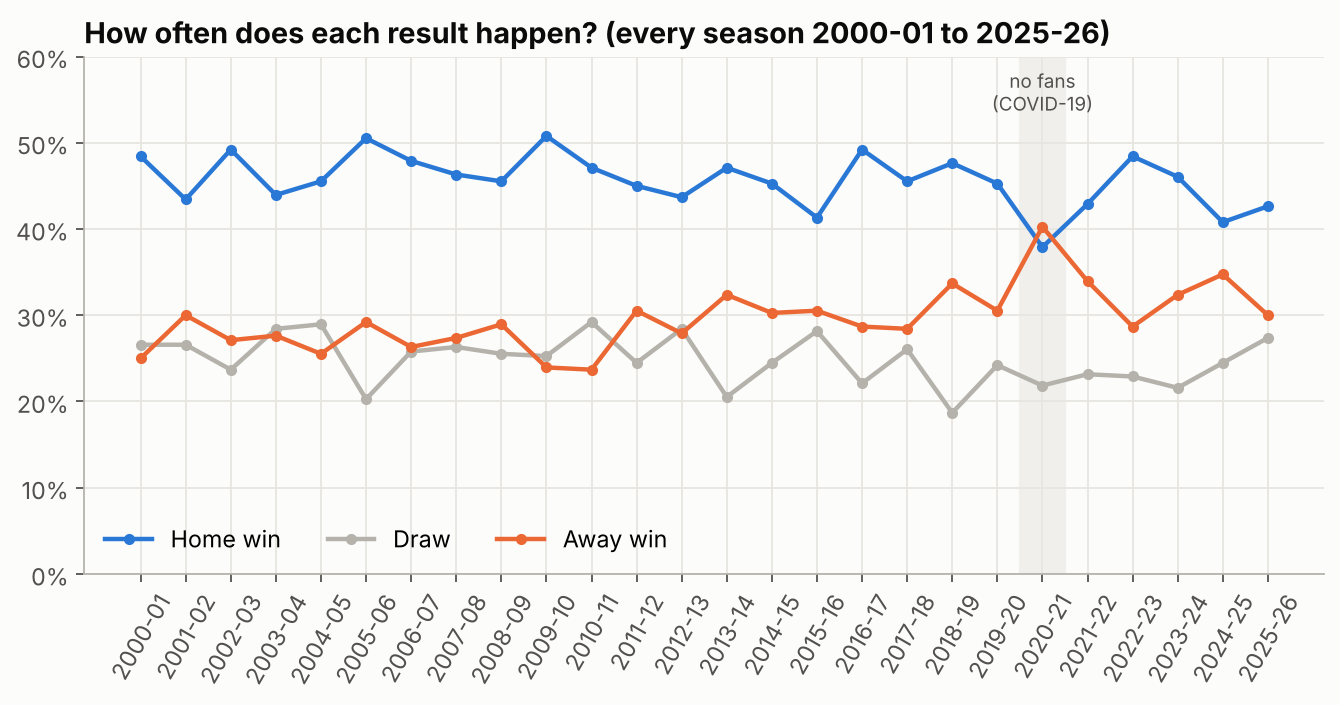

In [4]:
display(Image(FIG / 'outcomes_by_season.png'))

## 2. Features: only what is known before kick-off
The model may only use information available *before* the match (no shots or goals from the match itself, which would be cheating). `tests/test_no_leakage.py` checks this automatically: it changes results on one day and verifies that no feature on or before that day changes.

| Family | Example |
|---|---|
| Elo rating | long-term strength, updated after every match |
| Recent form | points per game in the last 5 matches |
| Weighted averages | goals, shots, shots on target, corners for/against |
| Home/away form | points per game in last 5 home (away) games |
| Season so far | points per game, goal difference, league position |
| Last season | final position, promoted or not |
| Rest & head-to-head | days since last match, record in last 6 meetings |

In [5]:
feats = features.load_features()
print(len(features.feature_columns()), 'features')
feats.loc[feats['season_label'].eq('2019-20'),
          ['date', 'home_team', 'away_team', 'result', 'home_elo', 'away_elo',
           'home_form5_ppg', 'away_form5_ppg', 'home_position', 'away_position']].tail()

49 features


,date,home_team,away_team,result,home_elo,away_elo,home_form5_ppg,away_form5_ppg,home_position,away_position
7595,2020-07-26,Leicester City,Manchester United,A,1476.001249,1538.494883,1.4,2.2,5.0,3.0
7596,2020-07-26,Manchester City,Norwich City,H,1648.532321,1248.286157,2.4,0.0,2.0,20.0
7597,2020-07-26,Newcastle United,Liverpool,A,1388.671747,1660.915879,0.4,2.0,13.0,1.0
7598,2020-07-26,Southampton,Sheffield United,H,1414.996342,1373.335076,1.8,1.4,12.0,8.0
7599,2020-07-26,West Ham United,Aston Villa,D,1400.531671,1305.599831,1.6,1.4,15.0,17.0


### Elo ratings computed by this project
The ratings tell the history of the league: Chelsea's rise in 2004, Manchester United under Ferguson, Manchester City from 2011, Liverpool under Klopp.

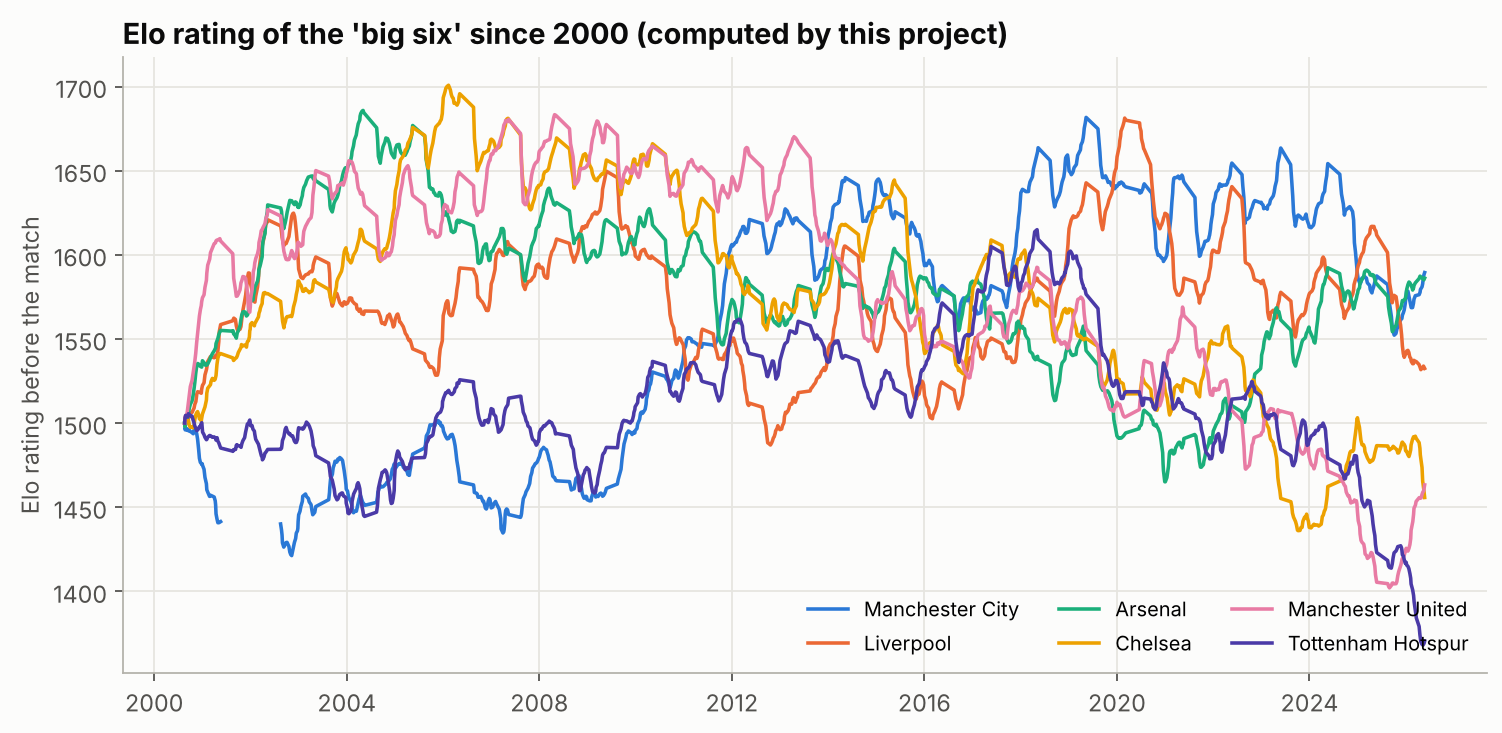

In [6]:
display(Image(FIG / 'elo_history.png'))

## 3. Honest evaluation: walk-forward by season
For each season from 2014-15 to 2025-26 we train on **all earlier seasons only** and predict the whole season. That's 12 × 380 = 4,560 test matches the model never saw. Model settings were tuned on 2010-11 to 2013-14 only (`reports/tuning_log.txt`).

We judge the probabilities, not only the hit rate:
* **Accuracy**: did the most likely outcome happen?
* **RPS** (Ranked Probability Score): the standard football metric. It punishes confident wrong predictions. Lower is better.

As a reference we also score the **bookmaker** (Bet365 odds converted to probabilities). Bookmakers are professional forecasters, so getting close to them is the real test. The odds are never given to the models.

In [7]:
results = pd.read_csv(config.RESULTS_CSV)
results.round(4)

,model,matches,accuracy,log_loss,brier,rps,predicted_draw_%
0,"Bookmaker (Bet365, benchmark)",4560,0.5474,0.9607,0.5693,0.1955,0.0000
1,Poisson goals model,4560,0.5364,0.9722,0.5775,0.1993,0.0000
2,Ensemble (LR + GB + Poisson),4560,0.5342,0.9743,0.5786,0.1996,0.0219
3,Logistic regression,4560,0.5340,0.9778,0.5805,0.2002,0.5702
4,Random forest,4560,0.5340,0.9776,0.5806,0.2005,0.0658
5,Gradient boosting,4560,0.5338,0.9806,0.5824,0.2010,0.5263
6,Elo only (logistic regression),4560,0.5333,0.9822,0.5836,0.2021,0.0000
7,Baseline: home-win rate,4560,0.4441,1.0688,0.6465,0.2326,0.0000


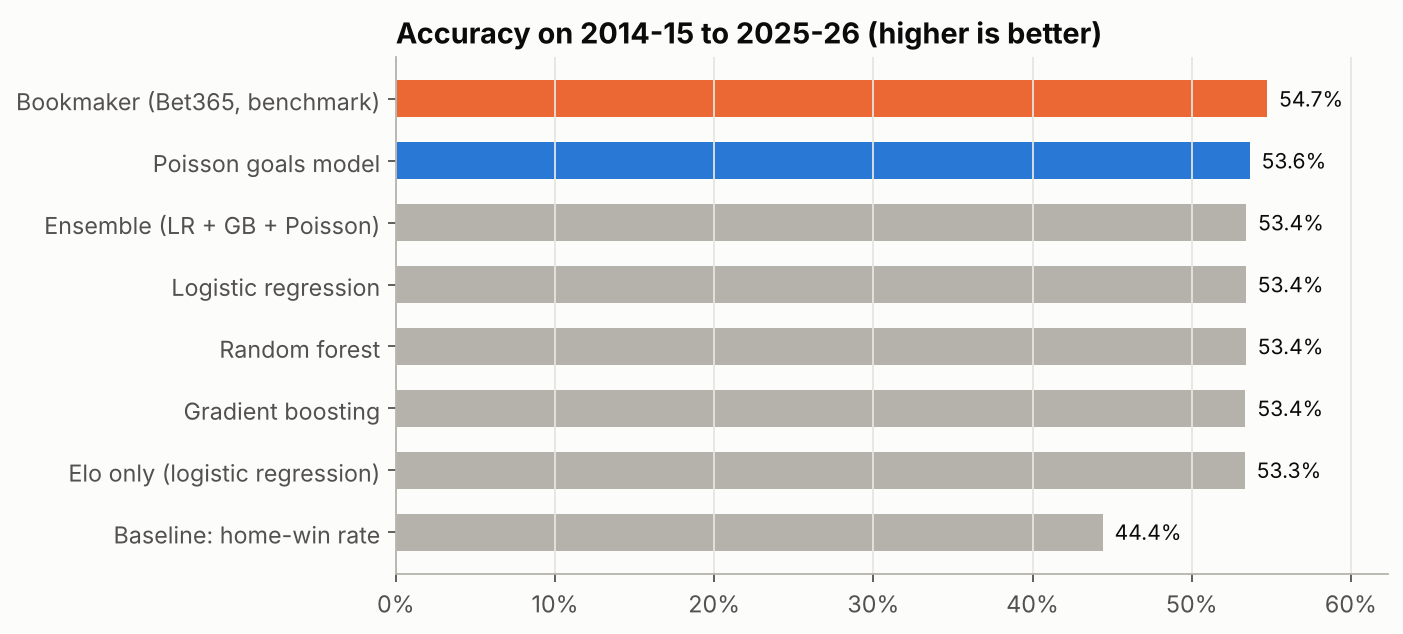

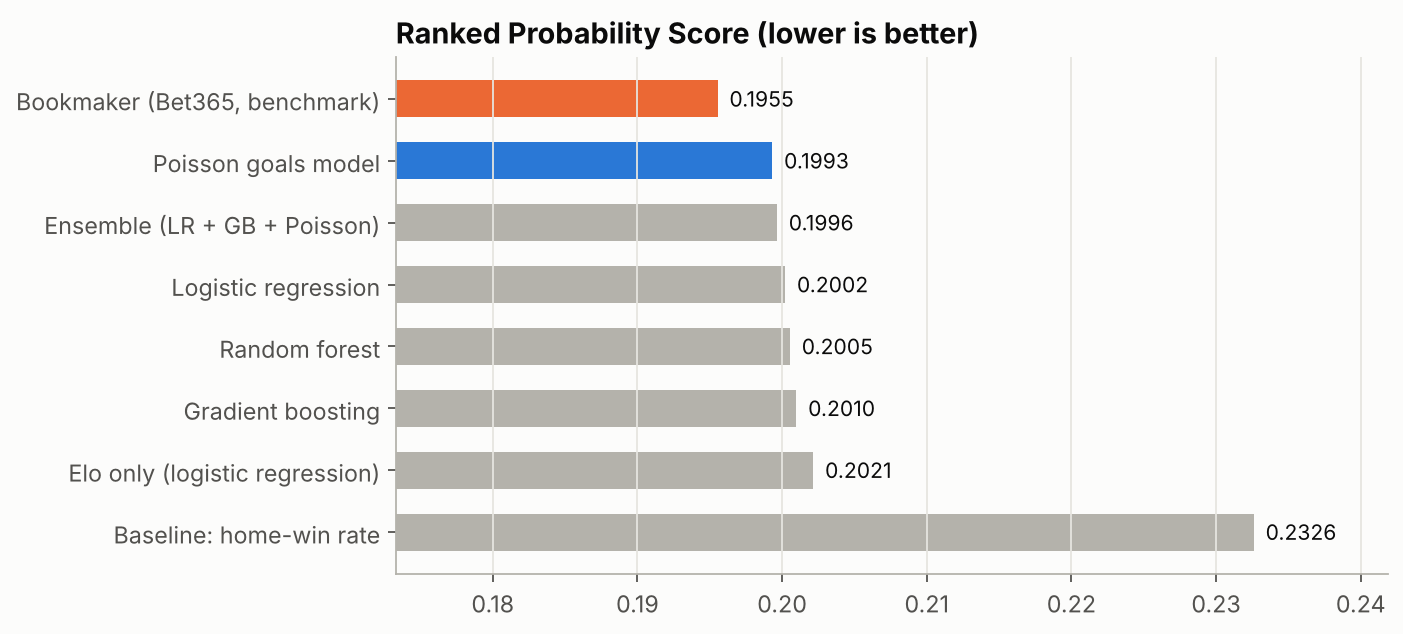

In [8]:
display(Image(FIG / 'model_accuracy.png'))
display(Image(FIG / 'model_rps.png'))

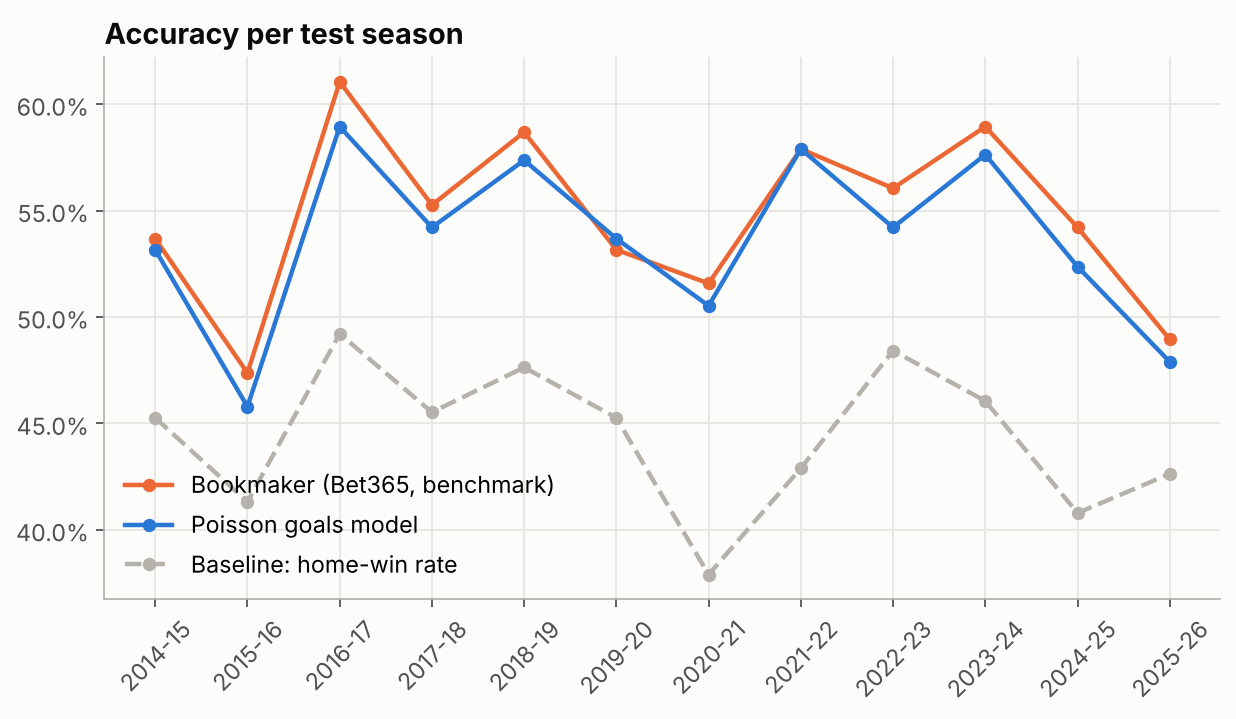

In [9]:
display(Image(FIG / 'accuracy_by_season.png'))

### Are the probabilities honest? (calibration)
If the model says 60 %, the event should happen about 60 % of the time. Points close to the dashed line = well calibrated.

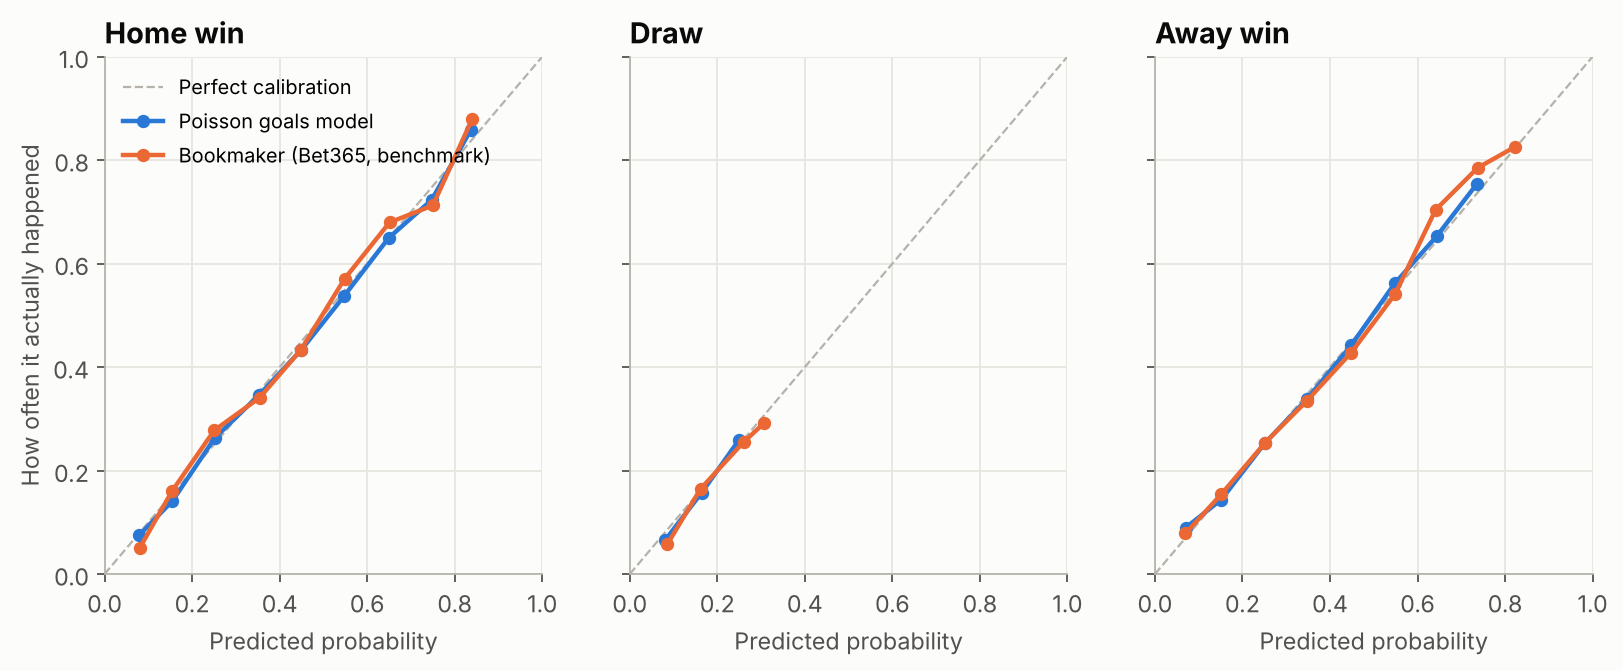

In [10]:
display(Image(FIG / 'calibration.png'))

### The draw problem
Draws are the hardest outcome: they're almost never the single most likely result, so models (and bookmakers) rarely predict them.

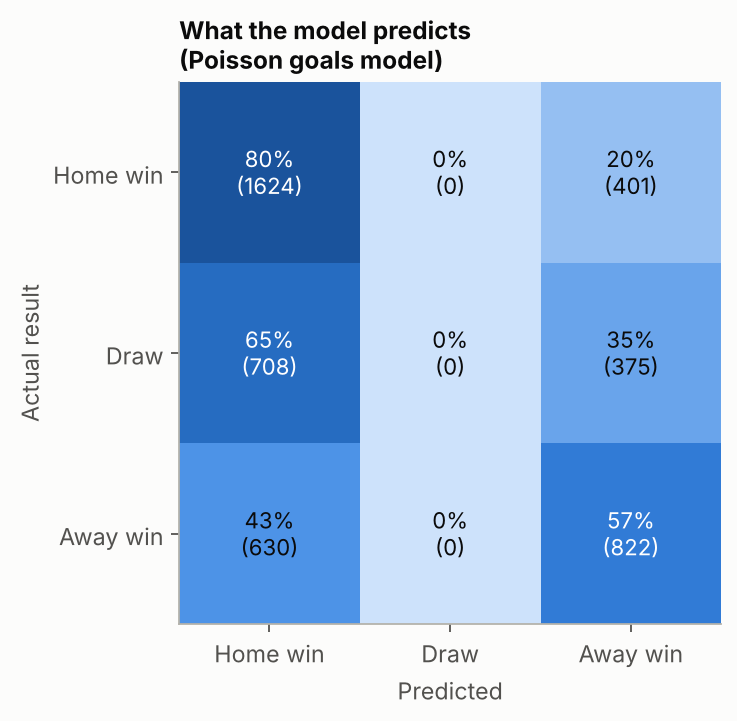

In [11]:
display(Image(FIG / 'confusion_matrix.png'))

### Which features matter?

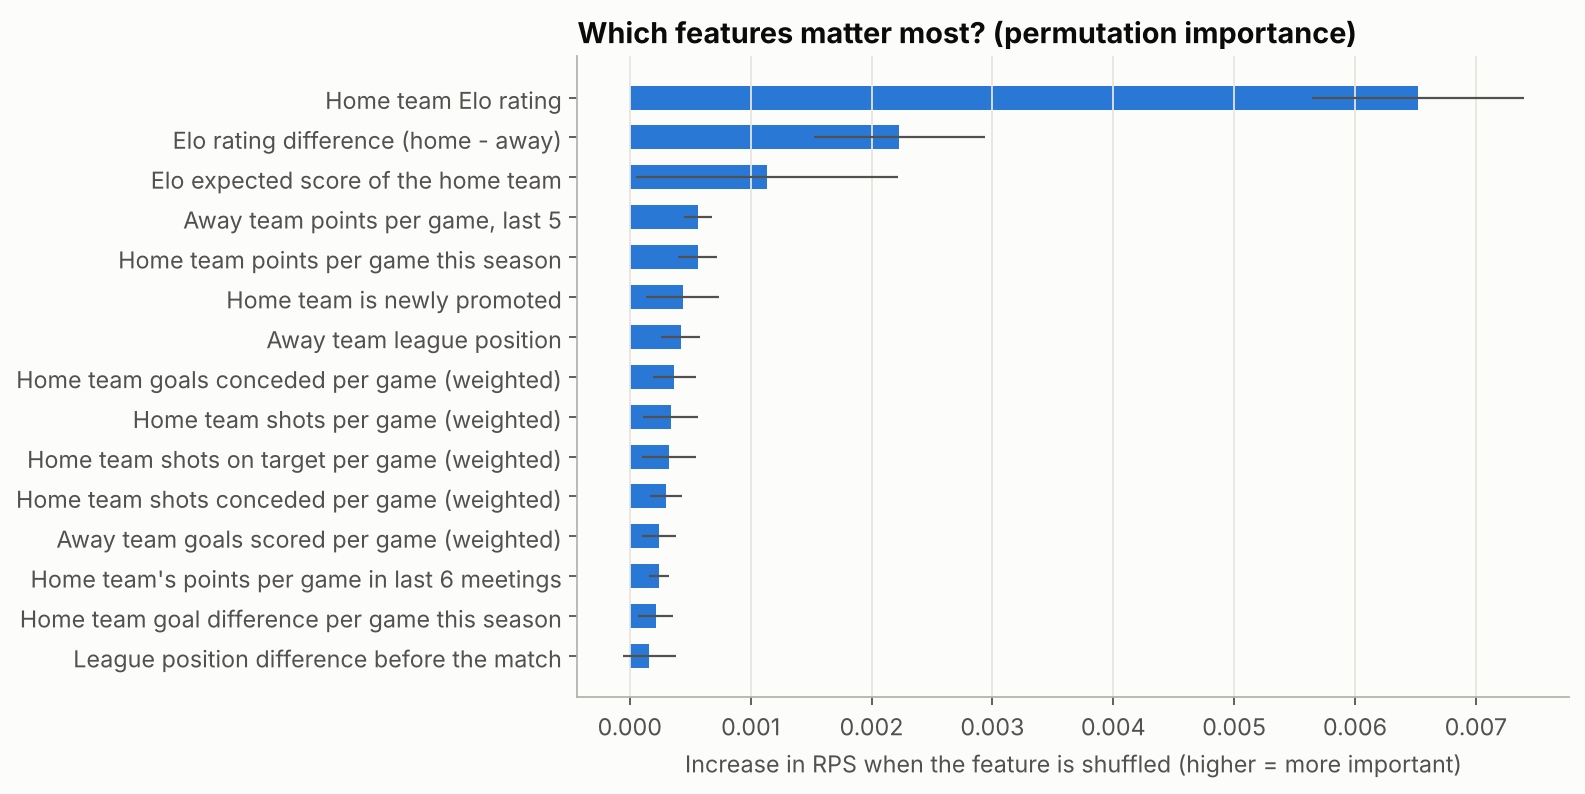

In [12]:
display(Image(FIG / 'feature_importance.png'))

## 4. Compared with the original project (v1)
The original project used one season (2019-20, whose data stopped in March 2020) and tested on its last 20 % of dates: only **38 matches**. On so few matches even "always pick the home team" ties with the best models, so you can't tell good models from lucky ones. That's why this version tests on 4,560 matches over 12 seasons.

,model,matches,accuracy
0,Elo only (logistic regression),38,0.579
1,Random forest,38,0.579
2,"Bookmaker (Bet365, benchmark)",38,0.553
3,Ensemble (LR + GB + Poisson),38,0.553
4,Poisson goals model,38,0.553
5,Logistic regression,38,0.553
6,Gradient boosting,38,0.553
7,Baseline: home-win rate,38,0.579
8,Original project (v1 random forest),38,0.475


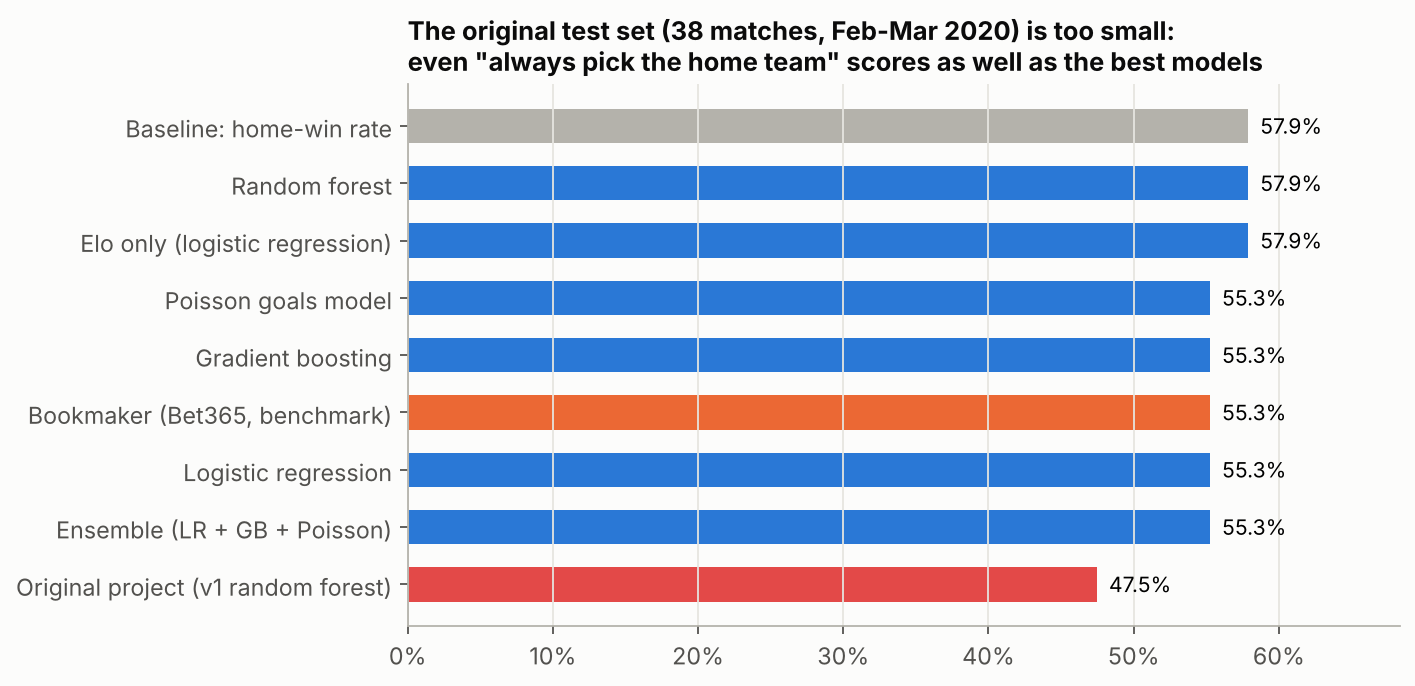

In [13]:
display(pd.read_csv(config.REPORTS_DIR / 'comparison_with_original.csv').round(3))
display(Image(FIG / 'season_2019_20_vs_original.png'))

## 5. Extra data: other competitions and players
We added the dates of every FA Cup, League Cup, Champions League and Europa League match and every international break (fatigue), plus Fantasy Premier League player data from 2016-17 (how influential the starting eleven is). Tested on 2018-19 to 2025-26 with the same walk-forward method:

In [14]:
ext = pd.read_csv(config.REPORTS_DIR / 'extended_results.csv')
ext[(ext['model'] == 'Poisson goals model') | (ext['feature_set'] == 'Bookmaker')][
    ['feature_set', 'accuracy', 'rps', 'rps_change', 'rps_change_low', 'rps_change_high']].round(4)

,feature_set,accuracy,rps,rps_change,rps_change_low,rps_change_high
2,Base (49 features),0.5388,0.2007,NaN,NaN,NaN
6,+ fatigue,0.5352,0.2011,0.0004,-0.0001,0.0011
10,+ players,0.5441,0.1998,-0.0008,-0.0018,0.0001
14,+ everything,0.5421,0.2002,-0.0005,-0.0016,0.0006
16,Bookmaker,0.5493,0.1966,NaN,NaN,NaN


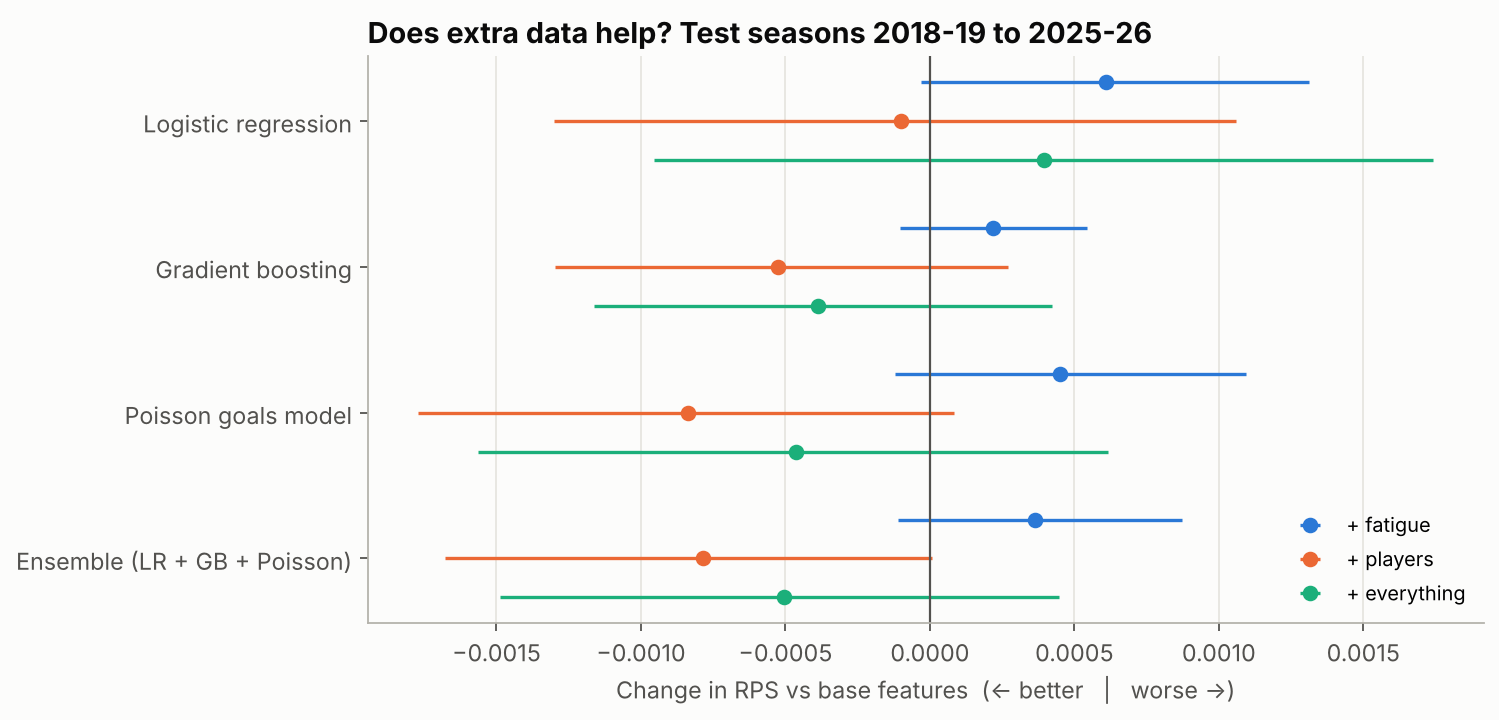

In [15]:
display(Image(FIG / 'extended_comparison.png'))

Player data helps a little; fatigue doesn't. The final model therefore uses the base features plus the player features.

## 6. Try it: predict a match
The final model is trained on all 26 seasons and uses each team's latest ratings and its most-used starting eleven.

In [16]:
from eplpred.predict import Predictor

predictor = Predictor(matches)
print(predictor.predict('Arsenal', 'Chelsea'))
print()
print(predictor.predict('Liverpool', 'Manchester City'))

Arsenal vs Chelsea
  Home win :  64.9%
  Draw     :  20.9%
  Away win :  14.2%
  Expected goals: 1.95 - 0.78 (most likely score 1-0)



Liverpool vs Manchester City
  Home win :  34.5%
  Draw     :  23.0%
  Away win :  42.4%
  Expected goals: 1.54 - 1.73 (most likely score 1-1)


## 7. Conclusions and limitations
See the README section *Results* and *Limitations* for the talking points. In short:
* More seasons made the models more stable and the evaluation trustworthy (4,560 test matches instead of ~75).
* Simple, well-designed features (especially Elo) carry most of the signal: Elo alone reaches 53.3 % accuracy, the best model 53.6 %.
* The classic Poisson goals model beat logistic regression, random forest and gradient boosting (best RPS).
* Knowing who plays (FPL player influence) helps a little; fatigue from other competitions doesn't.
* The bookmaker is still slightly better: it has information we don't have (injury news, confirmed line-ups, transfers).
* Football is noisy: even the best forecasters are right only about half the time.